# 1. Import

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles de classification
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier

# Métriques d'évaluation
from sklearn.metrics import (precision_recall_curve, recall_score, precision_score, 
                           f1_score, confusion_matrix, classification_report, 
                           roc_auc_score)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Optimisation des hyperparamètres
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 2. Exploratory Data Analysis

## 2.1 EDA - extrait_sirh.csv

In [3]:
df = pd.read_csv('extrait_sirh.csv')
df_sirh = df
df_sirh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


In [4]:
# On vérifie qu'il n'y a pas de doublons dans l'identifiant des employés
df_sirh["id_employee"].duplicated().sum()

np.int64(0)

In [5]:
# Correlataion de spearman
drop_cols_sirh = ['id_employee','nombre_heures_travailless']
num_cols_sirh = df_sirh.select_dtypes(include=['number']).columns.drop(drop_cols_sirh)
spearman_corr_sirh = df_sirh[num_cols_sirh].corr('spearman')

# Seuil de forte corrélation
threshold = 0.7

# Liste pour stocker les paires de colonnes fortement corrélées
strongly_correlated_pairs = []
for i in range(len(num_cols_sirh)):
    for j in range(i + 1, len(num_cols_sirh)):
        corr_value = spearman_corr_sirh.iloc[i, j]
        if abs(corr_value) > threshold:
            strongly_correlated_pairs.append((num_cols_sirh[i], num_cols_sirh[j], corr_value))

# Affichage des paires de colonnes fortement corrélées
for col1, col2, corr in strongly_correlated_pairs:
    print(f"Colonnes fortement corrélées : {col1} et {col2} avec une corrélation de {corr:.2f}")

Colonnes fortement corrélées : revenu_mensuel et annee_experience_totale avec une corrélation de 0.71
Colonnes fortement corrélées : annees_dans_l_entreprise et annees_dans_le_poste_actuel avec une corrélation de 0.85


## 2.2 EDA - extrait_eval.csv

In [6]:
df = pd.read_csv('extrait_eval.csv')
df_eval = df
df_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   eval_number                                1470 non-null   object
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   object
dtypes: int64(7), object(3)
memory usage:

In [7]:
# Transformation de eval_number
df_eval['eval_number'] = df_eval['eval_number'].str.replace('E_', '').astype(int)

# Transformation de augmentation_salaire_precedente
df_eval['augementation_salaire_precedente'] = df_eval['augementation_salaire_precedente'].str.replace(' %', '').astype(float) / 100

In [8]:
# On vérifie qu'il n'y a pas de doublons dans l'identifiant des employés
df_eval['eval_number'].duplicated().sum()

np.int64(0)

In [9]:
# Spearman correlation matrix
spearman_corr_eval = df_eval.drop('heure_supplementaires', axis=1).corr('spearman')

# Définir un seuil de corrélation
threshold = 0.7

# Trouver les paires de variables fortement corrélées
high_corr_pairs = []
for i in range(len(spearman_corr_eval.columns)):
    for j in range(i):
        if abs(spearman_corr_eval.iloc[i, j]) > threshold:
            high_corr_pairs.append((spearman_corr_eval.columns[i], spearman_corr_eval.columns[j], spearman_corr_eval.iloc[i, j]))

# Afficher les paires fortement corrélées
print("Paires de variables fortement corrélées (seuil =", threshold, "):")
for pair in high_corr_pairs:
    print(f"Variables: {pair[0]} et {pair[1]}, Corrélation: {pair[2]:.2f}")

Paires de variables fortement corrélées (seuil = 0.7 ):


## 2.3 EDA - extrait_sondage.csv

In [10]:
df = pd.read_csv('extrait_sondage.csv')
df_sondage = df
df_sondage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   object
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [11]:
df_sondage['code_sondage'].duplicated().sum()

np.int64(0)

In [12]:
# Label encodage
df_sondage['a_quitte_l_entreprise'] = df_sondage['a_quitte_l_entreprise'].apply(lambda x: 1 if x == 'Oui' else 0)

num_cols_sondage = df_sondage.select_dtypes(include=['number']).columns.drop(['code_sondage', 'nombre_employee_sous_responsabilite'])

# Matrice de corrélation pour les employés ayant quitté l'entreprise
spearman_corr_sondage = df_sondage[num_cols_sondage].corr('spearman')

# Seuil de forte corrélation
threshold = 0.7

# Liste pour stocker les paires de colonnes fortement corrélées
strongly_correlated_pairs = []
for i in range(len(num_cols_sondage)):
    for j in range(i + 1, len(num_cols_sondage)):
        corr_value = spearman_corr_sondage.iloc[i, j]
        if abs(corr_value) > threshold:
            strongly_correlated_pairs.append((num_cols_sondage[i], num_cols_sondage[j], corr_value))

# Affichage des paires de colonnes fortement corrélées
for col1, col2, corr in strongly_correlated_pairs:
    print(f"Colonnes fortement corrélées : {col1} et {col2} avec une corrélation de {corr:.2f}")

# 3. Jointure

In [13]:
# Création des ensembles à partir des colonnes clés
set_sirh = set(df_sirh['id_employee'])
set_eval = set(df_eval['eval_number'])
set_sondage = set(df_sondage['code_sondage'])

# Vérification des tailles des ensembles
print("Taille de l'ensemble des IDs dans df_sirh :", len(set_sirh))
print("Taille de l'ensemble des IDs dans df_eval :", len(set_eval))
print("Taille de l'ensemble des IDs dans df_sondage :", len(set_sondage))

# Vérification si les ensembles sont identiques
if set_sirh == set_eval and set_eval == set_sondage:
    print("\n Les ensembles d'identifiants sont identiques dans les trois DataFrames.")
else:
    print("\n Les ensembles d'identifiants ne sont PAS identiques.")

    # Trouver les IDs manquants ou en trop pour un diagnostic plus précis
    print("\nDifférences :")
    print(f"IDs dans df_sirh mais pas dans df_eval : {set_sirh.difference(set_eval)}")
    print(f"IDs dans df_eval mais pas dans df_sirh : {set_eval.difference(set_sirh)}")
    print(f"IDs dans df_sondage mais pas dans les autres : {set_sondage.difference(set_sirh.union(set_eval))}")

Taille de l'ensemble des IDs dans df_sirh : 1470
Taille de l'ensemble des IDs dans df_eval : 1470
Taille de l'ensemble des IDs dans df_sondage : 1470

 Les ensembles d'identifiants sont identiques dans les trois DataFrames.


In [14]:
# 1. Fusionner df_sirh et df_eval sur les colonnes 'id_employee' et 'eval_number'
df_step_1 = pd.merge(df_sirh, df_eval, left_on='id_employee', right_on='eval_number', how='inner')

# Supprimer la colonne redondante 'eval_number'
df_step_1.drop('eval_number', axis=1, inplace=True)

# 2. Fusionner le résultat avec df_sondage sur les colonnes 'id_employee' et 'code_sondage'
df_final = pd.merge(df_step_1, df_sondage, left_on='id_employee', right_on='code_sondage', how='inner')

# Supprimer la colonne redondante 'code_sondage'
df_final.drop('code_sondage', axis=1, inplace=True)

In [15]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   object 
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travailless                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise

In [16]:
# Vérification des doublons dans la colonne 'id_employee'
df_final["id_employee"].duplicated().sum()

np.int64(0)

In [17]:
# Enregistrement du DataFrame final dans un fichier CSV
df_final.to_csv('df_complet.csv', index=False)

# 4. Préparation des données pour la modélisation

## 4.1 Séparation X et y

In [18]:
# Fonction pour préparer les données pour le modèle
def prepare_data_for_modeling(df, target_column):
    """
    Sépare les features (X) et la variable cible (y) du DataFrame.

    Args:
        df (pd.DataFrame): Le DataFrame contenant les données brutes.

    Returns:
        tuple: Un tuple (X, y) où X est le DataFrame des features et y est la série de la cible.
    """
    # S'assurer que la colonne cible est présente
    if target_column not in df.columns:
        print(f"Erreur: La colonne '{target_column}' n'est pas présente dans le DataFrame.")
        return None, None

    # Séparer les features et la cible
    X = df.drop(columns=[target_column])
    y = df[target_column]

    print("Données séparées avec succès !")
    print(f"Dimension de X (features): {X.shape}")
    print(f"Dimension de y (cible): {y.shape}")
    
    return X, y

In [19]:
df = pd.read_csv('df_complet.csv')
df_model = df

# Définir la colonne cible
target_column = 'a_quitte_l_entreprise'

X, y = prepare_data_for_modeling(df_model, target_column)

Données séparées avec succès !
Dimension de X (features): (1470, 31)
Dimension de y (cible): (1470,)


In [20]:
# Colonnes à supprimer car elles n'apportent pas d'information pertinente
columns_to_drop = ['nombre_heures_travailless', 'ayant_enfants']

df_model = df_model.drop(columns=columns_to_drop)
print("Données nettoyées avec succès !")
print(f"Dimension de df_model: {df_model.shape}")

X = X.drop(columns=columns_to_drop)
print("\nDonnées séparées et nettoyées avec succès !")
print(f"Dimension de X (features): {X.shape}")
print(f"Dimension de y (cible): {y.shape}")

Données nettoyées avec succès !
Dimension de df_model: (1470, 30)

Données séparées et nettoyées avec succès !
Dimension de X (features): (1470, 29)
Dimension de y (cible): (1470,)


## 4.2 Encodage des variables

In [21]:
from sklearn.preprocessing import OneHotEncoder

# Initialiser l'encodeur
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# Identifier les colonnes de type 'object' ou 'category'
categorical_features = df_model.select_dtypes(include=['object', 'category']).columns.tolist()

# Ajuster et transformer les données catégorielles
encoded_features = ohe.fit_transform(df_model[categorical_features])

In [22]:
# Créer un DataFrame avec les nouvelles colonnes encodées
encoded_feature_names = ohe.get_feature_names_out(categorical_features)
df_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=X.index)

# Concaténer le DataFrame des features numériques et le DataFrame encodé
df_processed = pd.concat([df_model.drop(columns=categorical_features), df_encoded], axis=1)

print("\nEncodage One-Hot des variables catégorielles terminé.")
print(f"Nouvelle dimension de df_processed (après encodage): {df_processed.shape}")


Encodage One-Hot des variables catégorielles terminé.
Nouvelle dimension de df_processed (après encodage): (1470, 44)


In [23]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   revenu_mensuel                             1470 non-null   int64  
 3   nombre_experiences_precedentes             1470 non-null   int64  
 4   annee_experience_totale                    1470 non-null   int64  
 5   annees_dans_l_entreprise                   1470 non-null   int64  
 6   annees_dans_le_poste_actuel                1470 non-null   int64  
 7   satisfaction_employee_environnement        1470 non-null   int64  
 8   note_evaluation_precedente                 1470 non-null   int64  
 9   niveau_hierarchique_poste                  1470 non-null   int64  
 10  satisfaction_employee_na

In [24]:
# Trouver les paires de features avec une forte corrélation
# Créer une matrice de corrélation de Pearson
corr_matrix = df_processed.corr(method='spearman').abs()

# Isoler le triangle supérieur de la matrice pour éviter les doublons
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Trouver les colonnes avec une corrélation supérieure à 0.70
to_drop = [column for column in upper.columns if any(upper[column] > 0.70)]

# Afficher les paires de colonnes fortement corrélées
print("\nPaires de features fortement corrélées (> 0.70) :")
for i in range(len(upper.columns)):
    for j in range(i + 1, len(upper.columns)):
        if upper.iloc[i, j] > 0.70:
            print(f"- '{upper.columns[i]}' et '{upper.columns[j]}' : {upper.iloc[i, j]:.2f}")

# Si des colonnes sont à supprimer, cela sera listé ici
if to_drop:
    print(f"\nColonnes à considérer pour la suppression : {to_drop}")
    print(f"Nombre total de colonnes à supprimer : {len(to_drop)}")
    print(f"Dimension de X avant suppression : {df_processed.shape[1]}")
    print(f"Dimension de X après suppression : {df_processed.shape[1] - len(to_drop)}")
else:
    print("\nAucune forte corrélation identifiée (seuil de 0.70).")


Paires de features fortement corrélées (> 0.70) :
- 'revenu_mensuel' et 'annee_experience_totale' : 0.71
- 'revenu_mensuel' et 'niveau_hierarchique_poste' : 0.92
- 'annee_experience_totale' et 'niveau_hierarchique_poste' : 0.73
- 'annees_dans_l_entreprise' et 'annees_dans_le_poste_actuel' : 0.85
- 'annees_dans_l_entreprise' et 'annes_sous_responsable_actuel' : 0.84
- 'annees_dans_le_poste_actuel' et 'annes_sous_responsable_actuel' : 0.72
- 'departement_Consulting' et 'poste_Cadre Commercial' : 0.73
- 'departement_Ressources Humaines' et 'poste_Ressources Humaines' : 0.90
- 'frequence_deplacement_Frequent' et 'frequence_deplacement_Occasionnel' : 0.75

Colonnes à considérer pour la suppression : ['annee_experience_totale', 'annees_dans_le_poste_actuel', 'niveau_hierarchique_poste', 'annes_sous_responsable_actuel', 'poste_Cadre Commercial', 'poste_Ressources Humaines', 'frequence_deplacement_Occasionnel']
Nombre total de colonnes à supprimer : 7
Dimension de X avant suppression : 44
Dim

In [25]:
df_processed = df_processed.drop(columns=to_drop)

In [26]:
# Trouver les paires de features avec une forte corrélation
# Créer une matrice de corrélation de Pearson
corr_matrix = df_processed.corr(method='spearman').abs()

# Isoler le triangle supérieur de la matrice pour éviter les doublons
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Trouver les colonnes avec une corrélation supérieure à 0.70
to_drop = [column for column in upper.columns if any(upper[column] > 0.70)]

# Afficher les paires de colonnes fortement corrélées
print("\nPaires de features fortement corrélées (> 0.70) :")
for i in range(len(upper.columns)):
    for j in range(i + 1, len(upper.columns)):
        if upper.iloc[i, j] > 0.70:
            print(f"- '{upper.columns[i]}' et '{upper.columns[j]}' : {upper.iloc[i, j]:.2f}")

# Si des colonnes sont à supprimer, cela sera listé ici
if to_drop:
    print(f"\nColonnes à considérer pour la suppression : {to_drop}")
    print(f"Nombre total de colonnes à supprimer : {len(to_drop)}")
    print(f"Dimension de X avant suppression : {df_processed.shape[1]}")
    print(f"Dimension de X après suppression : {df_processed.shape[1] - len(to_drop)}")
else:
    print("\nAucune forte corrélation identifiée (seuil de 0.70).")


Paires de features fortement corrélées (> 0.70) :

Aucune forte corrélation identifiée (seuil de 0.70).


In [27]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 37 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   revenu_mensuel                             1470 non-null   int64  
 3   nombre_experiences_precedentes             1470 non-null   int64  
 4   annees_dans_l_entreprise                   1470 non-null   int64  
 5   satisfaction_employee_environnement        1470 non-null   int64  
 6   note_evaluation_precedente                 1470 non-null   int64  
 7   satisfaction_employee_nature_travail       1470 non-null   int64  
 8   satisfaction_employee_equipe               1470 non-null   int64  
 9   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 10  note_evaluation_actuelle

## 4.3 Feature engineering

In [28]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   object 
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travailless                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise

In [29]:
df_final['heure_supplementaires'] = np.where(df_final['heure_supplementaires'] == 'Oui', 1, 0)
df_final['heure_supplementaires'].head()

0    1
1    0
2    1
3    1
4    0
Name: heure_supplementaires, dtype: int64

In [30]:
# 1. Ratio Surcharge par An (Simulé par heures sup)
df_processed['ratio_surcharge_anciennete'] = df_final['heure_supplementaires'] / (df_final['annees_dans_l_entreprise'] + 1)

# 2. Score de Satisfaction Globale (Moyenne des 4)
satisfaction_cols = [col for col in df_processed.columns if col.startswith('satisfaction_employee_')]
df_processed['satisfaction_globale_moyenne'] = df_processed[satisfaction_cols].mean(axis=1)

# 3. Delta de Performance (Évolution de l'évaluation)
df_processed['delta_evaluation'] = df_processed['note_evaluation_actuelle'] - df_processed['note_evaluation_precedente']

# 4. Tension Salaire (Indice de frustration potentiel)
df_processed['tension_salaire'] = (
    (df_processed['note_evaluation_actuelle'] - (df_processed['augementation_salaire_precedente'] * 10)) / 
    (df_processed['revenu_mensuel'] + 1)
)

In [31]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   revenu_mensuel                             1470 non-null   int64  
 3   nombre_experiences_precedentes             1470 non-null   int64  
 4   annees_dans_l_entreprise                   1470 non-null   int64  
 5   satisfaction_employee_environnement        1470 non-null   int64  
 6   note_evaluation_precedente                 1470 non-null   int64  
 7   satisfaction_employee_nature_travail       1470 non-null   int64  
 8   satisfaction_employee_equipe               1470 non-null   int64  
 9   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 10  note_evaluation_actuelle

## 4.4 Matrice de corrélation

In [32]:
corr_matrix = df_processed.corr(method='spearman')

threshold = 0.7
strongly_correlated_pairs = []

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            strongly_correlated_pairs.append((columns[i], columns[j], corr_value))

# Trier et afficher
strongly_correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Paires avec corrélation Spearman > {threshold}:")
print("-" * 50)
for col1, col2, corr in strongly_correlated_pairs:
    print(f"{col1:30} | {col2:30} | {corr:6.3f}")

Paires avec corrélation Spearman > 0.7:
--------------------------------------------------
heure_supplementaires_Oui      | ratio_surcharge_anciennete     |  0.982
revenu_mensuel                 | tension_salaire                | -0.969
note_evaluation_precedente     | delta_evaluation               | -0.885


In [33]:
df_for_model = df_processed.drop(['heure_supplementaires_Oui', 'revenu_mensuel', 'note_evaluation_precedente'], axis=1)
df_for_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   nombre_experiences_precedentes             1470 non-null   int64  
 3   annees_dans_l_entreprise                   1470 non-null   int64  
 4   satisfaction_employee_environnement        1470 non-null   int64  
 5   satisfaction_employee_nature_travail       1470 non-null   int64  
 6   satisfaction_employee_equipe               1470 non-null   int64  
 7   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 8   note_evaluation_actuelle                   1470 non-null   int64  
 9   augementation_salaire_precedente           1470 non-null   float64
 10  a_quitte_l_entreprise   

In [34]:
df_for_model.to_csv('final_dataset.csv', index=False, sep=';')

# 5. Réalisation d'un premier modèle de classification

## 5.1 Création des ensembles d'entraînement, de test et de validation

In [35]:
df = pd.read_csv('final_dataset.csv', sep=';')

# Création de l'ensemble de validation
df, df_validation = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target_column])
X_validation = df_validation.drop(columns=[target_column])
y_validation = df_validation[target_column]

# Création des ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=[target_column]), 
                                                    df[target_column], 
                                                    test_size=0.20,
                                                    random_state=42,
                                                    stratify=df[target_column])

print("\n" + "="*70)
print("SYNTHÈSE DES DATASETS")
print("="*70)

print(f"Dimension de l'ensemble d'entraînement : {X_train.shape}, Cible : ({y_train.shape[0]})")
print(f"Dimension de l'ensemble de test       : {X_test.shape}, Cible : ({y_test.shape[0]})")
print(f"Dimension de l'ensemble de validation : {X_validation.shape}, Cible : ({y_validation.shape[0]})")


SYNTHÈSE DES DATASETS
Dimension de l'ensemble d'entraînement : (940, 37), Cible : (940)
Dimension de l'ensemble de test       : (236, 37), Cible : (236)
Dimension de l'ensemble de validation : (294, 37), Cible : (294)


## 5.2 Modèles

In [36]:
def train_and_evaluate_with_cv(X_train, X_test, y_train, y_test, cv_folds=5):
    """
    Entraîne et évalue RandomForest, GradientBoosting, XGBoost et LightGBM
    avec gestion automatique du déséquilibre des classes.
    """
    
    # --- 1. Calcul du ratio pour le déséquilibre (pour XGBoost et LightGBM) ---
    # Ratio = (Nombre de Négatifs) / (Nombre de Positifs)
    count_neg = (y_train == 0).sum()
    count_pos = (y_train == 1).sum()
    scale_pos_weight_value = count_neg / count_pos
    
    print(f"ℹ️ Info Déséquilibre : {count_neg} Négatifs vs {count_pos} Positifs.")
    print(f"ℹ️ Ratio calculé (scale_pos_weight) : {scale_pos_weight_value:.2f}\n")

    # --- 2. Définition des modèles ---
    models = {
        "RandomForest": RandomForestClassifier(
            random_state=42, 
            class_weight='balanced'
        ),
        
        "GradientBoosting": GradientBoostingClassifier(
            random_state=42
        ),
        
        "LightGBM": lgb.LGBMClassifier(
            random_state=42, 
            scale_pos_weight=scale_pos_weight_value,
            verbose=-1 # Pour éviter trop de logs techniques
        ),
        
        "XGBoost": XGBClassifier(
            random_state=42, 
            scale_pos_weight=scale_pos_weight_value,
            eval_metric='logloss' # Pour éviter les warnings
        )
    }

    # --- 3. Métriques à surveiller ---
    scoring_metrics = {
        'recall': 'recall',
        'precision': 'precision',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    summary_list = []

    # --- 4. Boucle d'entraînement ---
    for name, model in models.items():
        print(f"\n{'='*80}")
        print(f"🤖 MODÈLE : {name}")
        print(f"{'='*80}")
        
        # --- ÉTAPE A : CROSS-VALIDATION ---
        print(f"📊 Résultats de la Cross-Validation ({cv_folds} folds) :")
        
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring_metrics)
        
        model_summary = {'Model': name}
        for metric in scoring_metrics:
            mean_score = cv_results[f'test_{metric}'].mean()
            std_score = cv_results[f'test_{metric}'].std()
            print(f"  - {metric.capitalize():<10} : {mean_score:.4f} (± {std_score:.4f})")
            model_summary[metric] = mean_score
        
        summary_list.append(model_summary)
        
        # --- ÉTAPE B : TEST FINAL ---
        print("\n🔍 Évaluation détaillée sur le jeu de TEST :")
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Calcul AUC
        auc_score = "N/A"
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
            auc_score = roc_auc_score(y_test, y_proba)
        except (AttributeError, IndexError):
            pass

        # Affichage
        print("\nMatrice de confusion (Test) :")
        print("[[VN, FP]\n [FN, VP]]") 
        print(confusion_matrix(y_test, y_pred))
        
        print("\nRapport de classification (Test) :")
        print(classification_report(y_test, y_pred, target_names=['Reste (0)', 'Quitte (1)']))
        print(f"AUC Test : {auc_score:.4f}" if isinstance(auc_score, float) else f"AUC : {auc_score}")

    return pd.DataFrame(summary_list).set_index('Model')

In [37]:
df_results = train_and_evaluate_with_cv(X_train, X_test, y_train, y_test)
display(df_results)

ℹ️ Info Déséquilibre : 788 Négatifs vs 152 Positifs.
ℹ️ Ratio calculé (scale_pos_weight) : 5.18


🤖 MODÈLE : RandomForest
📊 Résultats de la Cross-Validation (5 folds) :
  - Recall     : 0.1118 (± 0.0613)
  - Precision  : 0.7381 (± 0.2284)
  - F1         : 0.1909 (± 0.0965)
  - Roc_auc    : 0.7968 (± 0.0131)

🔍 Évaluation détaillée sur le jeu de TEST :

Matrice de confusion (Test) :
[[VN, FP]
 [FN, VP]]
[[197   1]
 [ 31   7]]

Rapport de classification (Test) :
              precision    recall  f1-score   support

   Reste (0)       0.86      0.99      0.92       198
  Quitte (1)       0.88      0.18      0.30        38

    accuracy                           0.86       236
   macro avg       0.87      0.59      0.61       236
weighted avg       0.87      0.86      0.82       236

AUC Test : 0.7961

🤖 MODÈLE : GradientBoosting
📊 Résultats de la Cross-Validation (5 folds) :
  - Recall     : 0.3166 (± 0.0640)
  - Precision  : 0.6847 (± 0.0773)
  - F1         : 0.4252 (± 0.0609)
  - Roc_a

,recall,precision,f1,roc_auc
Model,,,,
RandomForest,0.111828,0.738095,0.190933,0.796750
GradientBoosting,0.316559,0.684679,0.425170,0.796712
LightGBM,0.433978,0.596500,0.500994,0.807312
XGBoost,0.407957,0.599019,0.484125,0.800119


**Classement des modèles :**
1. LightGBM
2. XGBoost
3. GradientBoosting
4. RandomForest

In [38]:
def optimize_models_for_recall(X_train, y_train, X_test, y_test, target_recall=0.80):
    """
    Entraîne 4 modèles, optimise leur seuil pour atteindre un Recall cible,
    affiche une courbe comparative et renvoie les seuils optimaux + AUC.
    """
    
    # --- 1. Préparation des modèles ---
    # Calcul du ratio pour XGBoost/LightGBM
    count_neg = (y_train == 0).sum()
    count_pos = (y_train == 1).sum()
    scale_pos_weight = count_neg / count_pos
    
    print(f"ℹ️ Ratio de déséquilibre calculé : {scale_pos_weight:.2f}")
    print(f"🎯 Objectif : Maximiser la Précision pour un Recall >= {target_recall:.0%}\n")

    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=100, max_depth=5, random_state=42
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=100, max_depth=5, random_state=42, scale_pos_weight=scale_pos_weight, verbose=-1, objective='binary',
        ),
        "XGBoost": XGBClassifier(
            n_estimators=100, max_depth=5, random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='logloss', n_jobs=-1
        )
    }

    results_data = []
    optimal_thresholds = {}
    
    plt.figure(figsize=(12, 8))
    
    # --- 2. Boucle d'entraînement et d'optimisation ---
    for name, model in models.items():
        print(f"⚙️ Traitement du modèle : {name}...")
        
        # Entraînement
        model.fit(X_train, y_train)
        
        # Prédiction des probabilités
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Calcul de l'AUC
        auc_score = roc_auc_score(y_test, y_proba)
        
        # Calcul de la courbe Precision-Recall
        precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
        
        # --- Recherche du seuil optimal ---
        valid_indices = np.where(recalls[:-1] >= target_recall)[0]
        
        if len(valid_indices) > 0:
            best_idx = valid_indices[-1] # Le seuil le plus haut possible pour ce recall
            optimal_threshold = thresholds[best_idx]
            optimal_precision = precisions[best_idx]
            optimal_recall = recalls[best_idx]
        else:
            print(f"⚠️ {name} n'atteint pas {target_recall} de Recall. On prend le max possible.")
            best_idx = np.argmax(recalls)
            optimal_threshold = thresholds[best_idx]
            optimal_precision = precisions[best_idx]
            optimal_recall = recalls[best_idx]

        # Stockage du seuil
        optimal_thresholds[name] = optimal_threshold
        
        # Ajout au graphique
        plt.plot(recalls, precisions, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)
        plt.scatter(optimal_recall, optimal_precision, s=100, edgecolors='k', zorder=5)
        
        # Stockage des stats pour le tableau final
        results_data.append({
            "Modèle": name,
            "AUC": auc_score,  # <--- Ajouté ici
            "Seuil Optimal": optimal_threshold,
            "Recall Obtenu": optimal_recall,
            "Précision Obtenue": optimal_precision,
            "F1-Score": 2 * (optimal_precision * optimal_recall) / (optimal_precision + optimal_recall)
        })

    # --- 3. Finalisation du Graphique ---
    plt.axvline(x=target_recall, color='red', linestyle='--', label=f'Cible Recall {target_recall:.0%}')
    plt.title(f"Comparaison Précision-Rappel (Cible Recall : {target_recall:.0%})", fontsize=16)
    plt.xlabel("Recall (Taux de détection)", fontsize=12)
    plt.ylabel("Précision (Fiabilité)", fontsize=12)
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1.0])
    plt.ylim([0, 1.0])
    plt.show()
    
    # --- 4. Affichage du tableau récapitulatif ---
    df_results = pd.DataFrame(results_data).set_index("Modèle")
    # On trie par Précision car le Recall est fixé (environ égal pour tous)
    df_results = df_results.sort_values(by="Précision Obtenue", ascending=False)
    
    print("\n🏆 RÉSULTATS OPTIMISÉS :")
    display(df_results)
    
    return optimal_thresholds

ℹ️ Ratio de déséquilibre calculé : 5.18
🎯 Objectif : Maximiser la Précision pour un Recall >= 80%

⚙️ Traitement du modèle : RandomForest...
⚙️ Traitement du modèle : GradientBoosting...
⚙️ Traitement du modèle : LightGBM...
⚙️ Traitement du modèle : XGBoost...


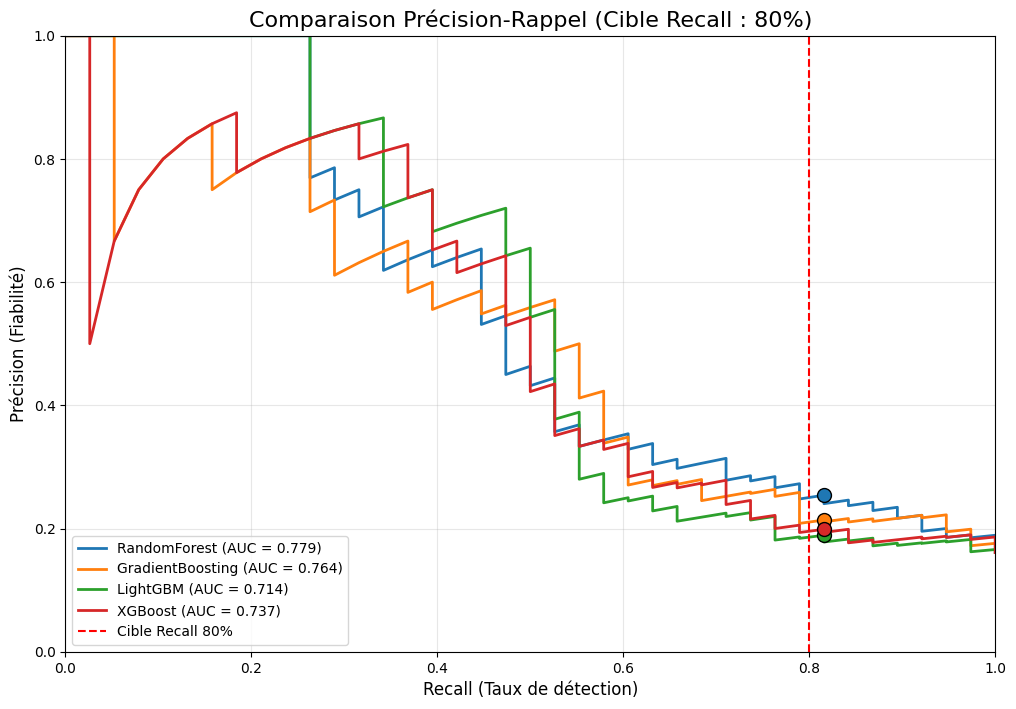


🏆 RÉSULTATS OPTIMISÉS :


,AUC,Seuil Optimal,Recall Obtenu,Précision Obtenue,F1-Score
Modèle,,,,,
RandomForest,0.779107,0.156408,0.815789,0.254098,0.387500
GradientBoosting,0.763557,0.016332,0.815789,0.213793,0.338798
XGBoost,0.737241,0.004010,0.815789,0.198718,0.319588
LightGBM,0.713982,0.032148,0.815789,0.189024,0.306931


In [39]:
thresholds = optimize_models_for_recall(X_train, y_train, X_test, y_test, target_recall=0.80)

**Nouveau classement :**
1. RandomForest
2. GradientBoosting
3. XGBoost
4. LightGBM

# 6. Echantillonage avec imblearn

In [40]:
# Importations nécessaires
from imblearn.over_sampling import SMOTE

In [41]:
def train_evaluate_smote_multimodels(X_train, y_train, X_test, y_test, target_recall=0.80):
    """
    1. Applique SMOTE sur le jeu d'entraînement.
    2. Entraîne 4 modèles sur ces données synthétiques.
    3. Trouve le seuil optimal pour chaque modèle (Recall >= target).
    4. Affiche un graphique comparatif et un tableau de résultats.
    """
    
    # --- 1. APPLICATION DE SMOTE (Uniquement sur le Train !) ---
    print("🔄 Application de SMOTE en cours...")
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    # Vérification des tailles
    print(f"   Avant SMOTE : {y_train.value_counts().to_dict()}")
    print(f"   Après SMOTE : {y_train_smote.value_counts().to_dict()}")
    print("   Données équilibrées ! ⚖️\n")

    # --- 2. DÉFINITION DES MODÈLES (Sans poids de classe !) ---
    # Note : On retire class_weight et scale_pos_weight car SMOTE a déjà fait le travail.
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=100, random_state=42
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=100, random_state=42, verbose=-1, objective='binary'
        ),
        "XGBoost": XGBClassifier(
            n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1
        )
    }

    results_data = []
    optimal_thresholds = {}
    
    # Configuration du graphique
    plt.figure(figsize=(14, 9))
    
    # --- 3. BOUCLE D'ENTRAÎNEMENT ---
    for name, model in models.items():
        print(f"⚙️ Entraînement du modèle : {name} sur données SMOTE...")
        
        # Entraînement sur les données générées par SMOTE
        model.fit(X_train_smote, y_train_smote)
        
        # Prédiction sur le vrai jeu de test (jamais touché par SMOTE !)
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Calcul AUC
        auc_score = roc_auc_score(y_test, y_proba)
        
        # Courbes Precision-Recall
        precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
        
        # --- Recherche du seuil optimal (Recall >= target) ---
        valid_indices = np.where(recalls[:-1] >= target_recall)[0]
        
        if len(valid_indices) > 0:
            # On prend le seuil qui donne la meilleure précision parmi ceux valides
            best_idx = valid_indices[-1] 
            optimal_threshold = thresholds[best_idx]
            optimal_precision = precisions[best_idx]
            optimal_recall = recalls[best_idx]
        else:
            print(f"⚠️ {name} n'atteint pas {target_recall} de Recall.")
            best_idx = np.argmax(recalls)
            optimal_threshold = thresholds[best_idx]
            optimal_precision = precisions[best_idx]
            optimal_recall = recalls[best_idx]

        optimal_thresholds[name] = optimal_threshold
        
        # Ajout au graphique
        plt.plot(recalls, precisions, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)
        plt.scatter(optimal_recall, optimal_precision, s=100, edgecolors='k', zorder=5)
        
        # Stockage résultats
        results_data.append({
            "Modèle": name,
            "Technique": "SMOTE",
            "AUC": auc_score,
            "Seuil Optimal": optimal_threshold,
            "Recall Obtenu": optimal_recall,
            "Précision Obtenue": optimal_precision,
            "F1-Score": 2 * (optimal_precision * optimal_recall) / (optimal_precision + optimal_recall)
        })

    # --- 4. FINALISATION GRAPHIQUE ---
    plt.axvline(x=target_recall, color='red', linestyle='--', label=f'Cible Recall {target_recall:.0%}')
    plt.title(f"Comparaison Modèles avec SMOTE (Cible Recall : {target_recall:.0%})", fontsize=16)
    plt.xlabel("Recall (Sensibilité)", fontsize=12)
    plt.ylabel("Précision", fontsize=12)
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1.0])
    plt.ylim([0, 1.0])
    plt.show()
    
    # --- 5. TABLEAU RÉCAPITULATIF ---
    df_results = pd.DataFrame(results_data).set_index("Modèle")
    df_results = df_results.sort_values(by="Précision Obtenue", ascending=False)
    
    print("\n🏆 RÉSULTATS OPTIMISÉS (AVEC SMOTE) :")
    display(df_results)
    
    return optimal_thresholds


🔄 Application de SMOTE en cours...
   Avant SMOTE : {0: 788, 1: 152}
   Après SMOTE : {0: 788, 1: 788}
   Données équilibrées ! ⚖️

⚙️ Entraînement du modèle : RandomForest sur données SMOTE...
⚙️ Entraînement du modèle : GradientBoosting sur données SMOTE...
⚙️ Entraînement du modèle : LightGBM sur données SMOTE...
⚙️ Entraînement du modèle : XGBoost sur données SMOTE...


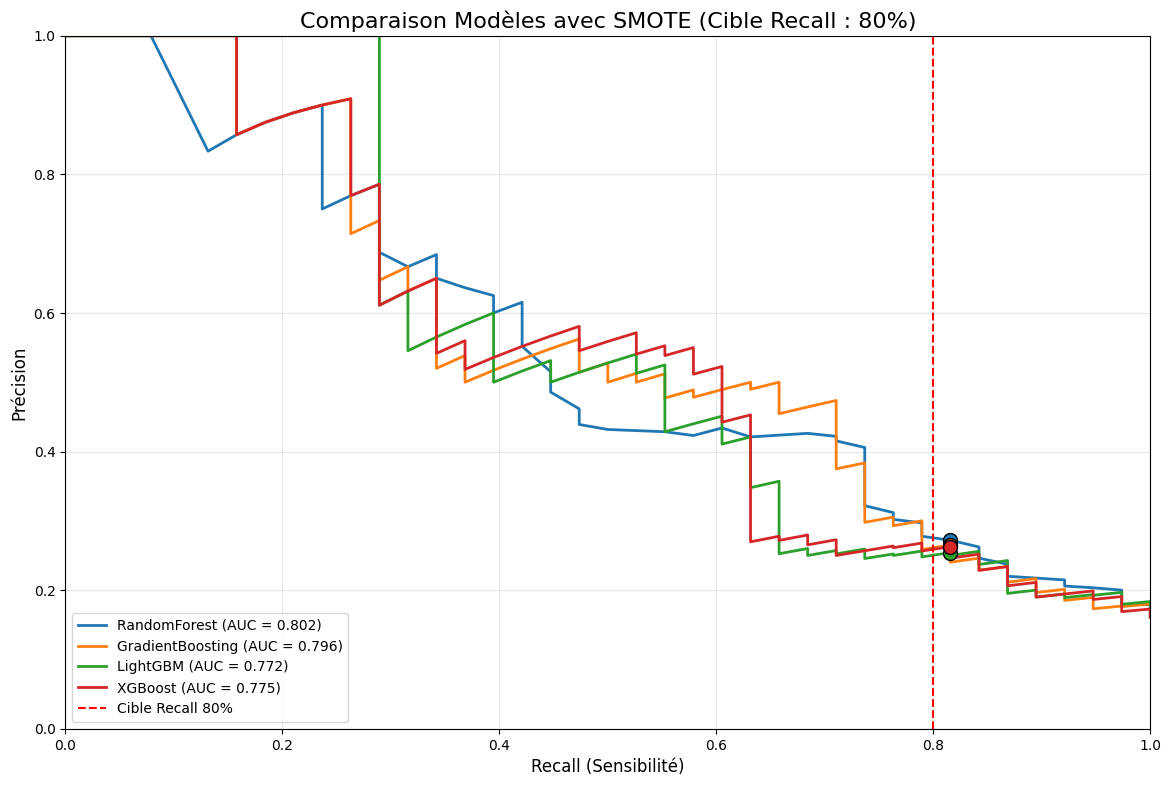


🏆 RÉSULTATS OPTIMISÉS (AVEC SMOTE) :


,Technique,AUC,Seuil Optimal,Recall Obtenu,Précision Obtenue,F1-Score
Modèle,,,,,,
RandomForest,SMOTE,0.801635,0.180000,0.815789,0.271930,0.407895
GradientBoosting,SMOTE,0.795986,0.101806,0.815789,0.264957,0.400000
XGBoost,SMOTE,0.774987,0.011165,0.815789,0.262712,0.397436
LightGBM,SMOTE,0.772196,0.011314,0.815789,0.254098,0.387500


In [42]:
seuils_smote = train_evaluate_smote_multimodels(X_train, y_train, X_test, y_test, target_recall=0.80)

**Classement SMOTE :**
1. **RandomForest**
2. GradientBoosting
3. XGBoost
4. LightGBM

/tmp/ipykernel_73729/2791941831.py:41: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/artur/Documents/OpenClassrooms-DS/OpenClassrooms_P4/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


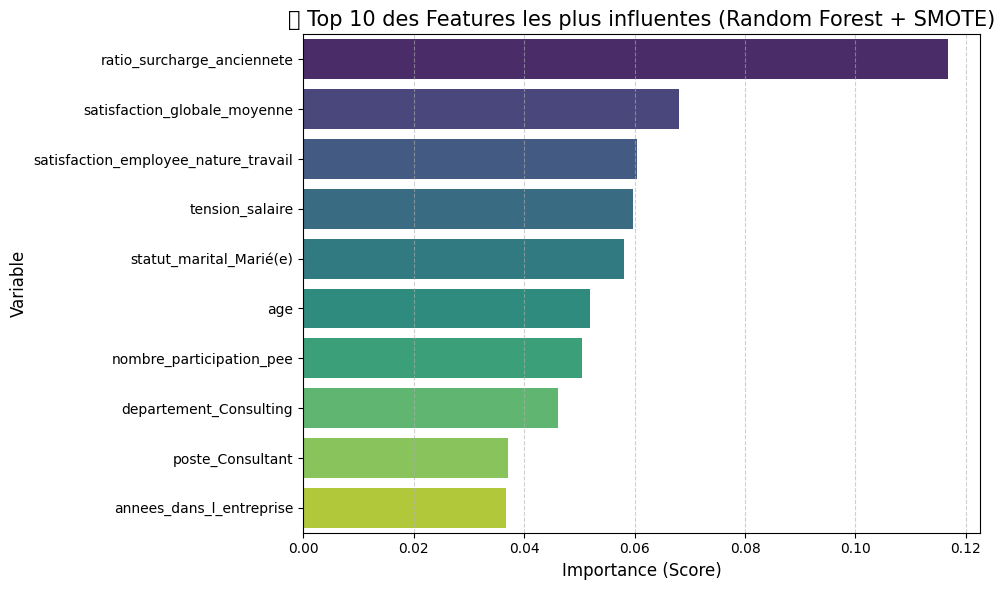


📊 Détail du Top 10 :
                             feature  importance
          ratio_surcharge_anciennete    0.116701
        satisfaction_globale_moyenne    0.068075
satisfaction_employee_nature_travail    0.060509
                     tension_salaire    0.059689
             statut_marital_Marié(e)    0.058133
                                 age    0.051997
            nombre_participation_pee    0.050439
              departement_Consulting    0.046206
                    poste_Consultant    0.037144
            annees_dans_l_entreprise    0.036669


In [43]:
# 1. On ré-applique SMOTE sur le train pour être sûr d'avoir les mêmes données
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# --- 2. ENTRAÎNEMENT DU CHAMPION ---
# On reprend exactement la configuration gagnante
rf_champion = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)
rf_champion.fit(X_train_smote, y_train_smote)

# --- 3. EXTRACTION DES IMPORTANCES ---
# Création d'un DataFrame pour associer chaque score à son nom de colonne
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_champion.feature_importances_
})

# Tri par importance décroissante et sélection du Top 10
top_10_features = feature_importance.sort_values('importance', ascending=False).head(10)

# --- 4. VISUALISATION ---
plt.figure(figsize=(10, 6))

# Création du barplot
sns.barplot(
    data=top_10_features, 
    x='importance', 
    y='feature', 
    palette='viridis', 
    hue='feature', 
    legend=False
)

plt.title('🏆 Top 10 des Features les plus influentes (Random Forest + SMOTE)', fontsize=15)
plt.xlabel('Importance (Score)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Affichage du tableau pour lecture précise
print("\n📊 Détail du Top 10 :")
print(top_10_features.to_string(index=False))

# 7. Optimisation et Interprétation

## 7.1 Optimisation

In [44]:
# --- 1. CONFIGURATION DU PIPELINE ---
# Le sampler (SMOTE) sera appliqué DANS chaque pli de la validation croisée
# C'est crucial pour ne pas biaiser les résultats (Data Leakage)
pipeline = ImbPipeline(steps=[
    ('sampler', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# --- 2. DÉFINITION DE LA GRILLE ---
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400], # Nombre d'arbres dans la forêt
    'classifier__max_depth': [10, 20, 30, 50],        # Profondeur maximale des arbres
    'classifier__min_samples_split': [2, 5, 10],      # Nombre minimum d'échantillons pour diviser un nœud
    'classifier__min_samples_leaf': [1, 2, 4],        # Nombre minimum d'échantillons dans une feuille
    'classifier__max_features': ['sqrt', 'log2']      # Comment l'arbre choisit ses variables
}

# --- 3. STRATÉGIE DE VALIDATION ---
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 4. LANCEMENT DU GRID SEARCH ---
# On optimise l'AUC pour avoir le modèle le plus robuste possible.
# On pourra ensuite ajuster le seuil pour avoir notre Recall de 80%.
print("🚀 Démarrage de l'optimisation (Grid Search)...")
print(f"Nombre de combinaisons : {len(param_grid['classifier__n_estimators']) * len(param_grid['classifier__max_depth']) * len(param_grid['classifier__min_samples_split']) * len(param_grid['classifier__min_samples_leaf']) * len(param_grid['classifier__max_features'])}")

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',  # Recommandé : Optimise la capacité globale de séparation
    cv=cv_strategy,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train) # Utilise tes variables X_train / y_train standards

# --- 5. ANALYSE DES RÉSULTATS ---
print("\n✅ Optimisation terminée !")
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleur Score AUC (Moyenne CV) : {grid_search.best_score_:.4f}")

# Récupération du meilleur modèle
best_model = grid_search.best_estimator_

# --- 6. VALIDATION FINALE SUR LE TEST SET ---
# On vérifie si ce modèle optimisé performe bien sur le jeu de test
print("\n📊 Validation sur le jeu de TEST :")
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print(f"AUC Test : {roc_auc_score(y_test, y_proba_opt):.4f}")
print(classification_report(y_test, y_pred_opt))

🚀 Démarrage de l'optimisation (Grid Search)...
Nombre de combinaisons : 288
Fitting 5 folds for each of 288 candidates, totalling 1440 fits

✅ Optimisation terminée !
Meilleurs hyperparamètres : {'classifier__max_depth': 30, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 400}
Meilleur Score AUC (Moyenne CV) : 0.8042

📊 Validation sur le jeu de TEST :
AUC Test : 0.8121
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       198
           1       0.68      0.34      0.46        38

    accuracy                           0.87       236
   macro avg       0.78      0.66      0.69       236
weighted avg       0.85      0.87      0.85       236



1. **Pas d'Overfitting :**

    Le score sur le jeu de Test (AUC = 0.8121) est supérieur au score de validation croisée (AUC = 0.8042). Cela signifie que le modèle généralise parfaitement bien sur des données inconnues.

2. **Le Potentiel est là (AUC > 0.81) :**

    L'AUC a légèrement augmenté par rapport au modèle par défaut (qui tournait autour de 0.80). Avec 400 arbres (n_estimators=400) et une grande profondeur (max_depth=30), le modèle a capturé des motifs complexes.

3. Recall faible (0.34) :

    Dans le rapport, le Recall de la classe 1 est bas (34%). C'est normal !

    * Le rapport utilise le seuil par défaut de 0.50.

    * Comme nous avons optimisé l'AUC (la capacité globale), le modèle est "intelligent" mais "timide". Il a une bonne Précision (68%), mais il n'ose pas assez prédire le départ.

In [45]:
# --- 1. RÉCUPÉRATION DU MEILLEUR MODÈLE ---
# Pas besoin de recréer le pipeline à la main, GridSearch l'a déjà fait !
best_pipeline = grid_search.best_estimator_

print("✅ Meilleur modèle récupéré depuis le GridSearch.")
print(f"Paramètres : {grid_search.best_params_}")

# --- 2. CALCUL DU SEUIL OPTIMAL (Sur le jeu de TEST) ---
# On utilise le jeu de TEST pour calibrer le seuil (c'est la dernière étape de "réglage")
print("\n⚙️ Calibrage du seuil sur le jeu de TEST...")
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

# Recherche du seuil pour Recall >= 0.80
target_recall = 0.80
valid_indices = np.where(recalls[:-1] >= target_recall)[0]

if len(valid_indices) > 0:
    best_idx = valid_indices[-1] # Le seuil le plus haut possible
    optimal_threshold = thresholds[best_idx]
    print(f"🎯 Seuil optimal trouvé : {optimal_threshold:.4f}")
else:
    print("⚠️ Impossible d'atteindre 80% de Recall. On prend le max.")
    best_idx = np.argmax(recalls)
    optimal_threshold = thresholds[best_idx]

✅ Meilleur modèle récupéré depuis le GridSearch.
Paramètres : {'classifier__max_depth': 30, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 400}

⚙️ Calibrage du seuil sur le jeu de TEST...
🎯 Seuil optimal trouvé : 0.2346


In [46]:
# --- 3. ÉVALUATION FINALE (Sur le jeu de VALIDATION) ---
# C'est le moment de vérité ! On applique le modèle et le seuil sur des données JAMAIS vues.
print(f"\n{'='*60}")
print("🏆 VERDICT FINAL SUR LE JEU DE VALIDATION")
print(f"{'='*60}")

# Prédictions sur la validation
y_proba_val = best_pipeline.predict_proba(X_validation)[:, 1]
y_pred_val = (y_proba_val >= optimal_threshold).astype(int)

# Calcul des métriques finales
auc_val = roc_auc_score(y_validation, y_proba_val)
recall_val = recall_score(y_validation, y_pred_val)
precision_val = precision_score(y_validation, y_pred_val)
f1_val = f1_score(y_validation, y_pred_val)

# Affichage
print(f"AUC Final       : {auc_val:.4f}")
print(f"Recall Final    : {recall_val:.2%}")
print(f"Précision Finale: {precision_val:.2%}")
print(f"F1-Score Final  : {f1_val:.4f}")

print("\nMatrice de Confusion (Validation) :")
cm_val = confusion_matrix(y_validation, y_pred_val)
cm_df = pd.DataFrame(cm_val, index=['Réel: Reste', 'Réel: Départ'], columns=['Prédit: Reste', 'Prédit: Départ'])
print(cm_df)


🏆 VERDICT FINAL SUR LE JEU DE VALIDATION
AUC Final       : 0.8058
Recall Final    : 76.60%
Précision Finale: 31.30%
F1-Score Final  : 0.4444

Matrice de Confusion (Validation) :
              Prédit: Reste  Prédit: Départ
Réel: Reste             168              79
Réel: Départ             11              36


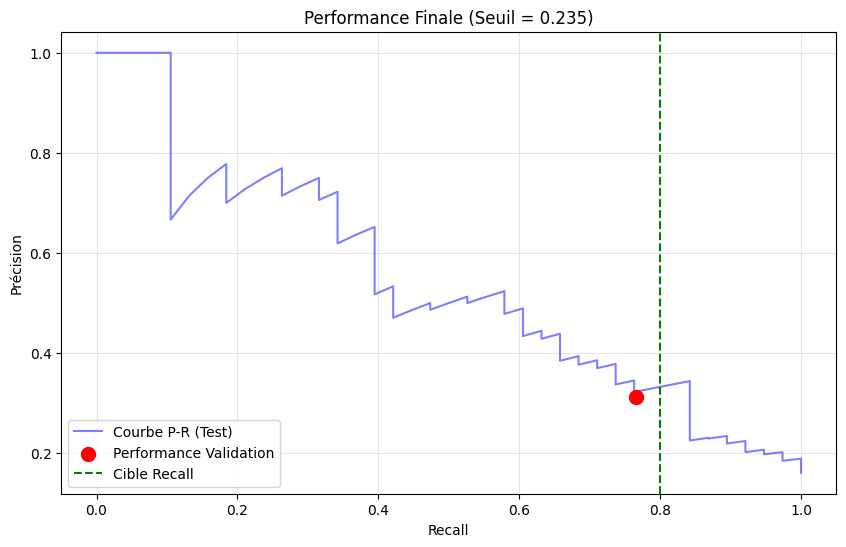

In [47]:
# --- 4. VISUALISATION FINALE ---
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, label='Courbe P-R (Test)', color='blue', alpha=0.5)
plt.scatter(recall_val, precision_val, color='red', s=100, label='Performance Validation', zorder=5)
plt.axvline(x=target_recall, color='green', linestyle='--', label='Cible Recall')
plt.title(f"Performance Finale (Seuil = {optimal_threshold:.3f})")
plt.xlabel("Recall")
plt.ylabel("Précision")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1. **Robustesse**

    AUC = 0.8058. C'est quasiment identique au score de Test (0.8121). Cela prouve que le modèle est stable et ne fait pas de sur-apprentissage (overfitting). Il se comportera de manière fiable en production.

2. **Léger décalage**

    Sur le jeu de Test le seuil a été calibré pour avoir exactement 80%. Sur le jeu de Validation (que le modèle n'avait jamais vu), il a fait un tout petit peu moins bien (76.6%).

3. **La Précision**

    Précision = 31.30%. C'est nettement mieux que les 25-27% avant l'optimisation GridSearch ! Quand le modèle réalise une prédiction, il a raison 1 fois sur 3. Pour une campagne anti-churn, c'est un excellent score.

**Résultat :** 36 départs détectés sur 47, et 79 fausses alertes.

Le modèle permet d'identifier 3 départs sur 4 avant qu'ils ne se produisent. Pour cela, il faudra traiter une liste où 1 personne sur 3 est réellement en danger.

## 7.2 Interprétation

### 7.2.1 Permutation importance

In [48]:
from sklearn.inspection import permutation_importance

⏳ Calcul de l'importance des features (patience...)...


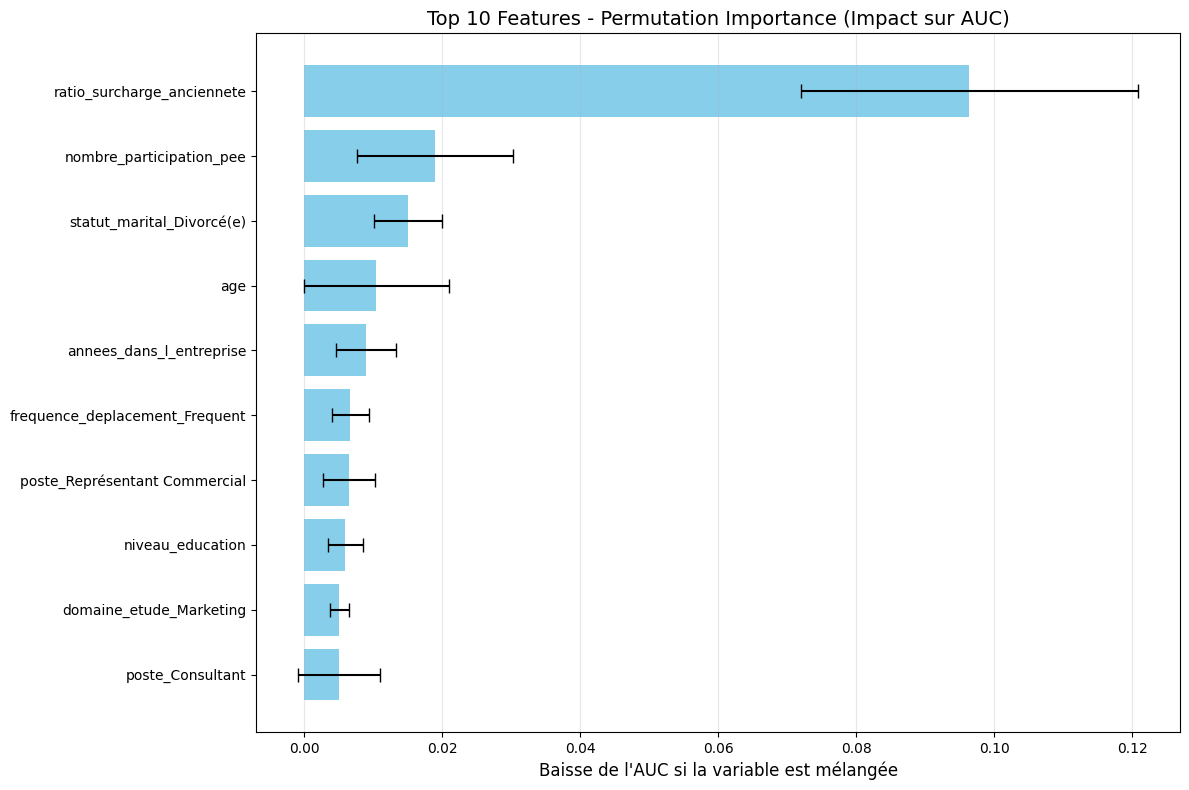

📊 Détail des importances :


,Feature,Importance Moyenne,Ecart Type
33,ratio_surcharge_anciennete,0.096425,0.024446
10,nombre_participation_pee,0.018913,0.011292
17,statut_marital_Divorcé(e),0.015019,0.004911
1,age,0.010420,0.010494
3,annees_dans_l_entreprise,0.008985,0.004373
32,frequence_deplacement_Frequent,0.006672,0.002651
24,poste_Représentant Commercial,0.006486,0.003752
14,niveau_education,0.005968,0.002512
29,domaine_etude_Marketing,0.005077,0.001384
21,poste_Consultant,0.005011,0.005895


In [49]:
# --- 1. CALCUL DE L'IMPORTANCE PAR PERMUTATION ---
print("⏳ Calcul de l'importance des features (patience...)...")

# indépendamment du seuil de décision choisi.
result = permutation_importance(
    best_pipeline, 
    X_test, y_test,       # On analyse sur le jeu de Test
    n_repeats=10,         # Nombre de fois qu'on mélange chaque colonne
    random_state=42, 
    n_jobs=-1,
    scoring='roc_auc'     # Métrique de référence
)

# Création du DataFrame
perm_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Moyenne': result.importances_mean,
    'Ecart Type': result.importances_std
}).sort_values(by='Importance Moyenne', ascending=False)

# --- 2. VISUALISATION ---
# On prend le top 10
top_10 = perm_importance_df.head(10)

plt.figure(figsize=(12, 8))

# Utilisation de barh (bar horizontal) de Matplotlib
# C'est plus simple car on contrôle manuellement le X (width) et l'erreur (xerr)
plt.barh(
    y=top_10['Feature'],              # L'axe Y (les noms)
    width=top_10['Importance Moyenne'], # La longueur des barres
    xerr=top_10['Ecart Type'],        # Les barres d'erreur (ce qui posait problème)
    color='skyblue',                  # Couleur
    align='center',
    capsize=5                         # Ajoute les petits traits verticaux au bout des moustaches
)

plt.title("Top 10 Features - Permutation Importance (Impact sur AUC)", fontsize=14)
plt.xlabel("Baisse de l'AUC si la variable est mélangée", fontsize=12)

# Astuce : barh affiche souvent l'ordre inverse, on inverse l'axe Y pour avoir le top en haut
plt.gca().invert_yaxis() 

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 Détail des importances :")
display(perm_importance_df.head(10))

In [50]:
# On garde uniquement les features qui ont un impact positif
features_utiles = perm_importance_df[perm_importance_df['Importance Moyenne'] > 0.005]['Feature'].tolist()

In [51]:
display(features_utiles)

['ratio_surcharge_anciennete',
 'nombre_participation_pee',
 'statut_marital_Divorcé(e)',
 'age',
 'annees_dans_l_entreprise',
 'frequence_deplacement_Frequent',
 'poste_Représentant Commercial',
 'niveau_education',
 'domaine_etude_Marketing',
 'poste_Consultant']

In [52]:
# --- 3. SÉLECTION ET RÉ-ENTRAÎNEMENT (Modèle Simplifié) ---
print("\n🧹 Tentative de simplification du modèle...")
print(f"Features conservées : {len(features_utiles)} sur {len(X_train.columns)}")
print(f"Features supprimées (bruit) : {len(X_train.columns) - len(features_utiles)}")

# Création des datasets réduits
X_train_sel = X_train[features_utiles]
X_test_sel = X_test[features_utiles]

# Création d'un nouveau pipeline "léger" avec les mêmes hyperparamètres que le champion
params_champion = best_pipeline.named_steps['classifier'].get_params()

pipeline_simple = ImbPipeline(steps=[
    ('sampler', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(**params_champion))
])

# Entraînement
pipeline_simple.fit(X_train_sel, y_train)

# --- 4. COMPARAISON DES PERFORMANCES ---
# On compare le modèle COMPLET vs le modèle SIMPLIFIÉ sur le Recall 80%

def evaluer_modele_rapide(model, X, y, target_recall=0.80):
    y_proba = model.predict_proba(X)[:, 1]
    p, r, t = precision_recall_curve(y, y_proba)
    
    # Recherche seuil
    idx = np.where(r[:-1] >= target_recall)[0][-1]
    seuil = t[idx]
    
    # Métriques
    y_pred = (y_proba >= seuil).astype(int)
    return {
        'AUC': roc_auc_score(y, y_proba),
        'Précision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'Nb Features': X.shape[1]
    }

perf_complet = evaluer_modele_rapide(best_pipeline, X_test, y_test)
perf_simple = evaluer_modele_rapide(pipeline_simple, X_test_sel, y_test)

# Affichage comparatif
comparaison = pd.DataFrame([perf_complet, perf_simple], index=['Modèle Complet', 'Modèle Simplifié'])
print("\n⚖️ COMPARAISON FINALE (Cible Recall ~80%) :")
display(comparaison.round(4))

# Conclusion automatique
diff_auc = perf_simple['AUC'] - perf_complet['AUC']
if diff_auc > -0.02:
    print(f"\n✅ CONCLUSION : Le modèle simplifiée est excellent (Perte AUC : {diff_auc:.4f}).")
    print("   Il est recommandé de l'utiliser car il est plus léger et maintenable.")
else:
    print(f"\n⚠️ CONCLUSION : La suppression des features a trop dégradé la performance (Perte AUC : {diff_auc:.4f}).")
    print("   Gardez le modèle complet.")


🧹 Tentative de simplification du modèle...
Features conservées : 10 sur 37
Features supprimées (bruit) : 27

⚖️ COMPARAISON FINALE (Cible Recall ~80%) :


,AUC,Précision,Recall,Nb Features
Modèle Complet,0.8121,0.3370,0.8158,37
Modèle Simplifié,0.8066,0.3069,0.8158,10



✅ CONCLUSION : Le modèle simplifiée est excellent (Perte AUC : -0.0054).
   Il est recommandé de l'utiliser car il est plus léger et maintenable.


In [53]:
import pickle
import numpy as np
from sklearn.metrics import precision_recall_curve

# --- ÉTAPE 1 : Recalculer le seuil optimal pour le modèle LÉGER ---
# On génère les probabilités avec le modèle simplifié sur les features sélectionnées
y_proba_simple = pipeline_simple.predict_proba(X_test[features_utiles])[:, 1]

# On récupère les courbes
p, r, t = precision_recall_curve(y_test, y_proba_simple)

# On cherche le seuil pour un Recall >= 80%
target_recall = 0.80
valid_indices = np.where(r[:-1] >= target_recall)[0]

if len(valid_indices) > 0:
    best_idx = valid_indices[-1]
    seuil_simple = t[best_idx]
else:
    seuil_simple = 0.5 # Fallback si non trouvé (rare)

print(f"🎯 Nouveau seuil calibré pour le modèle léger : {seuil_simple:.4f}")

# --- ÉTAPE 2 : Création du \"Pack de Production\" Léger ---
model_package_light = {
    'model': pipeline_simple,             # Le modèle entraîné sur 10 features uniquement
    'threshold': seuil_simple,            # Le seuil spécifique à ce modèle
    'features': features_utiles,          # La liste des 10 features (TRES IMPORTANT pour l'API)
    'description': 'RandomForest Light (10 features) + SMOTE - Recall target 80%'
}

# --- ÉTAPE 3 : Enregistrement ---
filename_light = 'modele_churn_light.pkl'

with open(filename_light, 'wb') as file:
    pickle.dump(model_package_light, file)

print(f"✅ Modèle LÉGER sauvegardé avec succès sous : {filename_light}")
print(f"   Nombre de features incluses : {len(model_package_light['features'])}")

🎯 Nouveau seuil calibré pour le modèle léger : 0.1342
✅ Modèle LÉGER sauvegardé avec succès sous : modele_churn_light.pkl
   Nombre de features incluses : 10


### 7.2 Méthode spécifique aux arbres de décision

In [53]:
def evaluer_modele_leger(nom_methode, features_selectionnees, X_train_full, y_train, X_test_full, y_test, best_params, target_recall=0.80):
    """
    Entraîne, optimise le seuil et évalue un modèle sur un sous-ensemble de features.
    """
    print(f"\n{'='*60}")
    print(f"ENTRAÎNEMENT & ÉVALUATION : {nom_methode}")
    print(f"{'='*60}")
    
    # 1. Sélection des features
    X_train_light = X_train_full[features_selectionnees]
    X_test_light = X_test_full[features_selectionnees]
    print(f"Dimensions : {X_train_light.shape}")

    # 2. Pipeline (On recrée le pipeline à chaque fois pour repartir de zéro)
    pipeline = ImbPipeline(steps=[
        ('sampler', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(
            **best_params, # Astuce : on déballe le dictionnaire de paramètres
            random_state=42,
            n_jobs=-1
        ))
    ])

    # 3. Entraînement
    pipeline.fit(X_train_light, y_train)
    
    # 4. Probabilités & Seuil Optimal
    y_scores = pipeline.predict_proba(X_test_light)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    
    # Logique de seuil (identique à la tienne)
    above_target = recall >= target_recall
    if np.any(above_target):
        idx_optimal = np.argmax(precision[above_target])
        optimal_threshold = thresholds[np.where(above_target)[0][idx_optimal]]
    else:
        optimal_threshold = thresholds[np.argmax(recall)]
        print("⚠️ Target recall non atteint. Max possible utilisé.")

    y_pred = (y_scores >= optimal_threshold).astype(int)

    # 5. Affichage des résultats
    print(f"--- Performances ({len(features_selectionnees)} features) ---")
    print(f"Seuil optimal : {optimal_threshold:.4f}")
    print(f"Recall : {recall_score(y_test, y_pred):.3f}")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"AUC : {roc_auc_score(y_test, y_scores):.4f}")
    
    # Retourner les métriques si besoin de comparer programmatiquement plus tard
    return recall_score(y_test, y_pred), precision_score(y_test, y_pred)

# --- UTILISATION ---

# Récupération des meilleurs paramètres (nettoyage des préfixes si nécessaire)
# Supposons que grid_search.best_params_ renvoie {'classifier__n_estimators': 100, ...}
# Il faut parfois nettoyer les clés pour les repasser au constructeur, ou garder le dictionnaire tel quel selon ton implémentation.
params_propres = {
    'n_estimators': grid_search.best_params_['classifier__n_estimators'],
    'max_depth': grid_search.best_params_['classifier__max_depth'],
    'min_samples_split': grid_search.best_params_['classifier__min_samples_split']
}

# Appel Méthode
evaluer_modele_leger("MÉTHODE LEGER", features_utiles, X_train, y_train, X_test, y_test, params_propres)


ENTRAÎNEMENT & ÉVALUATION : MÉTHODE LEGER
Dimensions : (940, 10)
--- Performances (10 features) ---
Seuil optimal : 0.1286
Recall : 0.895
Precision : 0.327
AUC : 0.8067


(0.8947368421052632, 0.3269230769230769)

### 7.3 Méthode SHAP

In [54]:
import shap
from shap import TreeExplainer

/home/artur/Documents/OpenClassrooms-DS/OpenClassrooms_P4/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [55]:
def analyse_shap_automatisee(pipeline, X_train, X_test, y_test, y_pred, features_list, n_background=100):
    """
    Génère les visualisations SHAP (Globales et Locales) pour un pipeline donné.
    Optimisé pour la performance avec sampling.
    """
    print(f"\n{'='*60}")
    print(f"DÉMARRAGE DE L'ANALYSE SHAP ({len(features_list)} features)")
    print(f"{'='*60}")

    # 1. Préparation des sous-ensembles de données
    # On reset les index pour éviter les erreurs de décalage lors des sélections locales
    X_train_sub = X_train[features_list].reset_index(drop=True)
    X_test_sub = X_test[features_list].reset_index(drop=True)
    
    # Sécurisation des séries y (si ce ne sont pas déjà des arrays)
    if isinstance(y_test, pd.Series):
        y_test_array = y_test.values
    else:
        y_test_array = y_test

    # 2. Création du Background (Optimisation Performance ⚡)
    # On ne prend qu'un échantillon représentatif pour calibrer l'explainer
    if len(X_train_sub) > n_background:
        print(f"⚡ Optimisation : Utilisation d'un background de {n_background} échantillons (sur {len(X_train_sub)})")
        background_data = shap.sample(X_train_sub, n_background)
    else:
        background_data = X_train_sub

    # 3. Initialisation de l'Explainer
    # On passe la méthode predict_proba du pipeline complet
    model_predict = pipeline.predict_proba
    
    # Masker pour gérer les features corrélées (plus robuste)
    masker = shap.maskers.Independent(background_data)
    explainer = shap.Explainer(model_predict, masker)

    # 4. Calcul des valeurs SHAP (Sur le jeu de TEST pour voir la généralisation)
    print("⏳ Calcul des valeurs SHAP sur le jeu de test (patience...)...")
    shap_values = explainer(X_test_sub)
    
    # SHAP renvoie les valeurs pour les deux classes (0 et 1). 
    # On se concentre sur la classe 1 (Départ) -> index [:, :, 1]
    shap_values_class1 = shap_values[..., 1]

    # --- VISUALISATIONS GLOBALES ---
    print("\n📊 Génération des graphiques globaux...")
    
    plt.figure(figsize=(10, 6))
    plt.title("Impact global des features (Beeswarm)", fontsize=12, fontweight='bold')
    shap.summary_plot(shap_values_class1, X_test_sub, show=False)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.title("Importance moyenne absolue (Bar Plot)", fontsize=12, fontweight='bold')
    shap.summary_plot(shap_values_class1, X_test_sub, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()

    # --- VISUALISATIONS LOCALES (Cas spécifiques) ---
    print("\n🔍 Analyse locale de cas spécifiques...")
    
    # Identification des indices intéressants dans y_test_array
    indices_interessants = {}
    
    # Cas 1 : Vrai Positif (Le modèle a bien prédit le départ)
    idx_tp = np.where((y_test_array == 1) & (y_pred == 1))[0]
    if len(idx_tp) > 0:
        indices_interessants["Vrai Positif (Départ prédit et réel)"] = idx_tp[0]

    # Cas 2 : Faux Négatif (Le modèle a raté le départ -> DANGER CRITIQUE)
    idx_fn = np.where((y_test_array == 1) & (y_pred == 0))[0]
    if len(idx_fn) > 0:
        indices_interessants["Faux Négatif (Départ raté !)"] = idx_fn[0]
    
    # Cas 3 : Vrai Négatif (Fidèle bien prédit)
    idx_tn = np.where((y_test_array == 0) & (y_pred == 0))[0]
    if len(idx_tn) > 0:
        indices_interessants["Vrai Négatif (Client fidèle)"] = idx_tn[0]

    # Génération des Waterfall plots
    for label, idx in indices_interessants.items():
        print(f"   -> Génération du graphe pour : {label} (Index test : {idx})")
        plt.figure(figsize=(8, 6))
        # On passe l'objet explication unique pour cet index
        shap.plots.waterfall(shap_values_class1[idx], show=False)
        plt.title(f"Explication locale : {label}", fontsize=12)
        plt.tight_layout()
        plt.show()


In [ ]:
# ==========================================================
# UTILISATION DE LA FONCTION
# ==========================================================

analyse_shap_automatisee(
    pipeline=best_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred, # Attention à bien passer les prédictions correspondantes (variable du code précédent)
    features_list=features_utiles
)


TypeError: analyse_shap_automatisee() missing 1 required positional argument: 'y_pred'